In [22]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score
import matplotlib.pyplot as plt

from mealpy import FloatVar, ABC
from scipy.spatial.distance import cdist

In [47]:
data = pd.read_csv("./results/pca_data.csv")
data.head(20)

,fecha,referencia,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,04/06/2001,P1,-2.173814,0.560687,-0.244653,-0.000022,-0.198642,-0.297102,-0.449977,-0.315806,-0.283185,-0.048349
1,04/06/2001,P2,-2.135326,0.504553,-0.095536,-0.305302,-0.183530,0.056558,-0.207734,-0.030956,0.008387,-0.057170
2,04/06/2001,P3,-2.165984,0.458176,-0.002323,-0.326949,-0.166642,0.099856,-0.208867,0.031741,0.089761,0.017689
3,04/06/2001,P4,-2.211613,0.503966,-0.129927,-0.042172,-0.189566,-0.223255,-0.443616,-0.230362,-0.179810,0.050264
4,04/07/2001,P1,-2.324292,0.460397,-0.136303,0.202740,-0.166470,-0.296635,-0.488494,-0.353747,-0.337112,0.184335
5,04/07/2001,P2,-2.132548,0.532214,-0.262256,0.078161,-0.227430,-0.337815,-0.472315,-0.422092,-0.392760,-0.015021
6,04/07/2001,P3,-2.117197,0.478984,-0.206697,0.078746,-0.231596,-0.325558,-0.468654,-0.420190,-0.383090,0.023730
7,04/07/2001,P4,-2.098488,0.522425,-0.254046,0.106607,-0.230658,-0.215664,-0.346504,-0.424520,-0.464356,0.012026
8,20/03/2002,P1,-2.358286,0.339262,-0.034405,0.217801,-0.236129,-0.071839,-0.443520,-0.288653,-0.345643,0.393474
9,20/03/2002,P2,-2.237500,0.425845,-0.233494,0.152536,-0.242958,-0.155881,-0.544733,-0.161736,-0.370111,0.375676


## Entrenamiento para clasificación con K-Means

Para realizar un entrenamiento no supervisado con una base de datos de parámetros químicos, la mejor opción es utilizar un Mapa Auto-Organizado (SOM) o un Autoencoder. Sin embargo, dado que ya se tiene los componentes principales (PCA), la técnica más robusta y estándar para encontrar grupos (clusters) es el K-Means Clustering potenciado por una Red Neuronal para validación.

### Preparación de los datos (Inputs del PCA)

Usaremos los componentes que explican la mayor parte de la varianza (según tu tabla, los primeros 5 o 6 son los más informativos).

In [64]:
# Método del codo

def elbow_method(x_data):
    # Determinamos el número óptimo de clusters (Método del Codo)
    wcss = []
    for i in range(1, 11):
        kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
        kmeans.fit(x_data)
        wcss.append([i, kmeans.inertia_])

    wcss_df = pd.DataFrame(wcss, columns=['n_cluster', 'wcss'])

    sns.lineplot(data=wcss_df, x='n_cluster', y='wcss', marker='o')

    # Determinacion de punto de cambio de pendiente (codo)
    wcss_df['dwcss'] = wcss_df['wcss'].diff()
    wcss_df['dn_cluster'] = wcss_df['n_cluster'].diff()
    wcss_df['slope'] = wcss_df['dwcss']/wcss_df['dn_cluster']

    wcss_df['d_slope'] = wcss_df['slope'].diff()

    elbow_index = wcss_df[wcss_df['d_slope']<0].first_valid_index()
    elbow_point = wcss_df.loc[elbow_index]

    print(wcss_df)

    sns.scatterplot(x=[elbow_point['n_cluster']], y=[elbow_point['wcss']], color='red', s=80, zorder=5)

    for x, y in zip(wcss_df["n_cluster"], wcss_df["wcss"]):
        plt.annotate(f'{x, int(y)}', (x, y), textcoords="offset points", xytext=(15,10), ha='center', fontsize=9)

    plt.title('Método del Codo para detectar Clusters')
    plt.xlabel('Número de clusters')
    plt.ylabel('WCSS (Inercia)')
    plt.grid(linestyle='--', alpha=0.5)
    plt.savefig('./graphs/training/codo_metodo_nclusters.png')
    plt.show()

   n_cluster         wcss        dwcss  dn_cluster        slope     d_slope
0          1  4420.603746          NaN         NaN          NaN         NaN
1          2  3040.639014 -1379.964732         1.0 -1379.964732         NaN
2          3  2276.695657  -763.943357         1.0  -763.943357  616.021375
3          4  1482.193365  -794.502291         1.0  -794.502291  -30.558934
4          5  1181.755830  -300.437535         1.0  -300.437535  494.064756
5          6  1103.891450   -77.864380         1.0   -77.864380  222.573155
6          7   914.523968  -189.367482         1.0  -189.367482 -111.503102
7          8   758.104399  -156.419569         1.0  -156.419569   32.947913
8          9   649.307808  -108.796591         1.0  -108.796591   47.622978
9         10   585.083764   -64.224045         1.0   -64.224045   44.572546


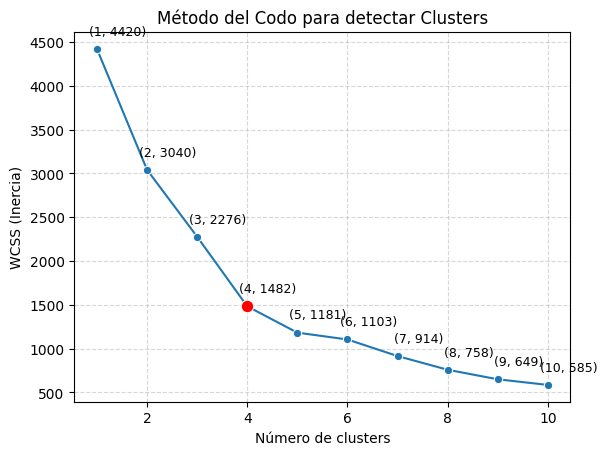

In [68]:
# Usamos los resultados del PCA
# Seleccionamos, por ejemplo, los primeros 5 componentes principales
X_unsupervised = data.iloc[:, 2:5] 

elbow_method(X_unsupervised)

Para n_clusters = 2, el promedio es: 0.439
Para n_clusters = 3, el promedio es: 0.447
Para n_clusters = 4, el promedio es: 0.465
Para n_clusters = 5, el promedio es: 0.450
Para n_clusters = 6, el promedio es: 0.456
Para n_clusters = 7, el promedio es: 0.469
Para n_clusters = 8, el promedio es: 0.473
Para n_clusters = 9, el promedio es: 0.434
Para n_clusters = 10, el promedio es: 0.387


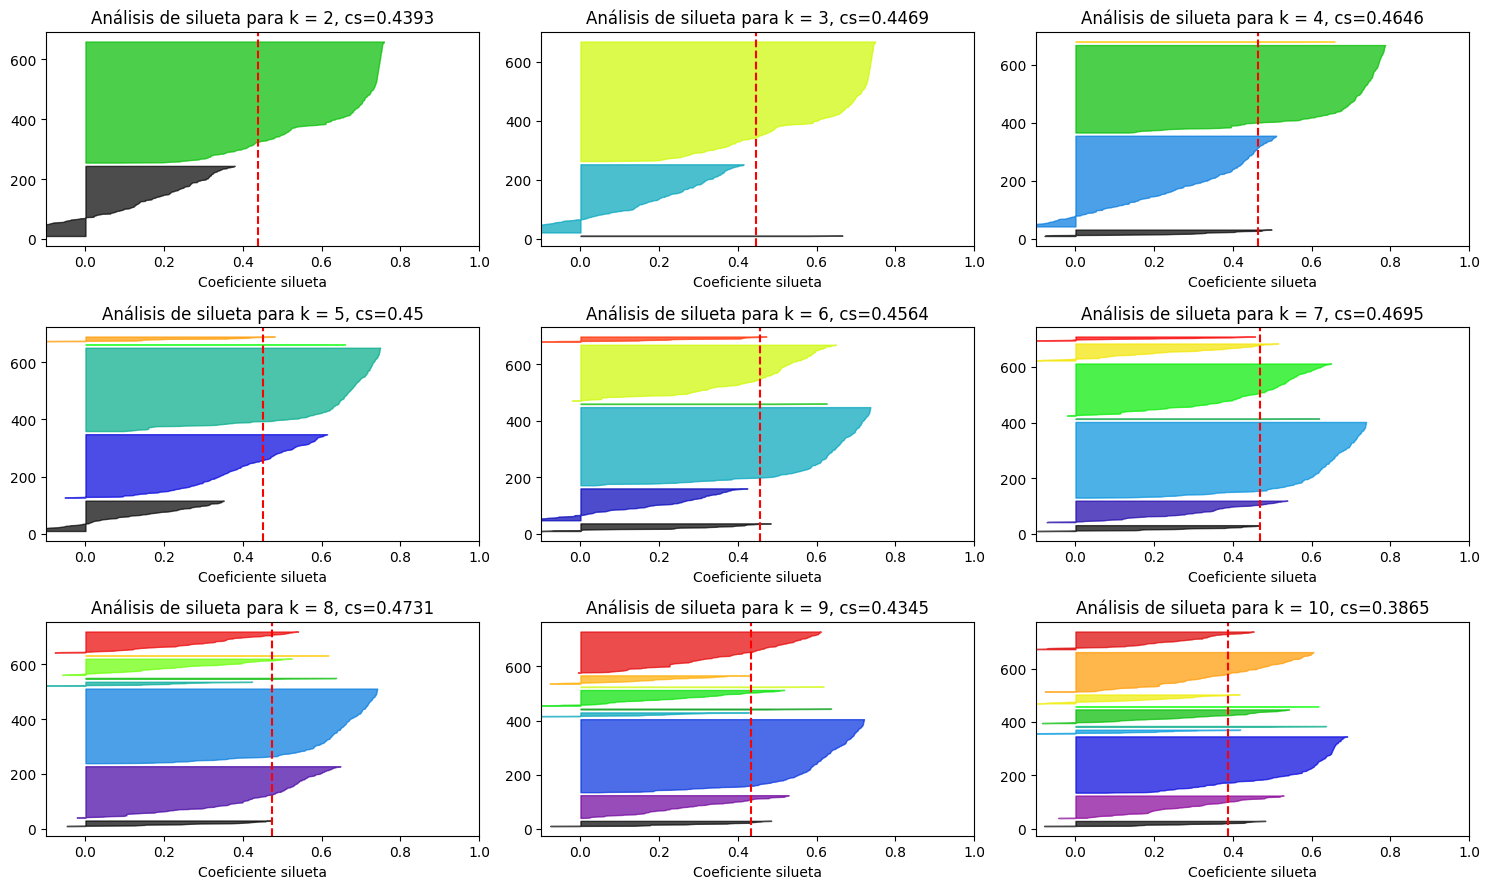

In [69]:
# metodo de coeficiente de silueta
n_range_clusters = 9
n_rows = 3
n_cols = 3

silhouette_data = np.zeros([n_range_clusters, 2])

i_row = 0
i_col = 0

fig, ax_1 = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3*n_rows))

for n_clusters_opt in range(2, n_range_clusters+2):
    # Crear el subplot
    ax_1[i_row, i_col].set_xlim([-0.1, 1])
    
    # Entrenar el modelo
    clusterer = KMeans(n_clusters=n_clusters_opt, random_state=10)
    cluster_labels = clusterer.fit_predict(X_unsupervised)

    # Calcular el promedio de silueta (la línea punteada)
    silhouette_avg = silhouette_score(X_unsupervised, cluster_labels)
    print(f"Para n_clusters = {n_clusters_opt}, el promedio es: {silhouette_avg:.3f}")

    # Calcular el coeficiente de cada muestra
    sample_silhouette_values = silhouette_samples(X_unsupervised, cluster_labels)

    y_lower = 10
    for i in range(n_clusters_opt):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters_opt)
        ax_1[i_row, i_col].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        y_lower = y_upper + 10 

    ax_1[i_row, i_col].axvline(x=silhouette_avg, color="red", linestyle="--")
    ax_1[i_row, i_col].set_title(f"Análisis de silueta para k = {n_clusters_opt}, cs={np.round(silhouette_avg,4)}")
    ax_1[i_row, i_col].set_xlabel('Coeficiente silueta')

    silhouette_data[n_clusters_opt-2, 0] = n_clusters_opt
    silhouette_data[n_clusters_opt-2, 1] = silhouette_avg

    # Actualizando contadores
    if i_col < n_cols-1:
        i_col += 1
    else:
        i_col = 0
        if i_row < n_rows-1:
            i_row += 1
        else:
            i_row = 0

plt.tight_layout()
plt.savefig(f'./graphs/training/graf_silueta.png')
plt.show()

El n_cluster optimo 8


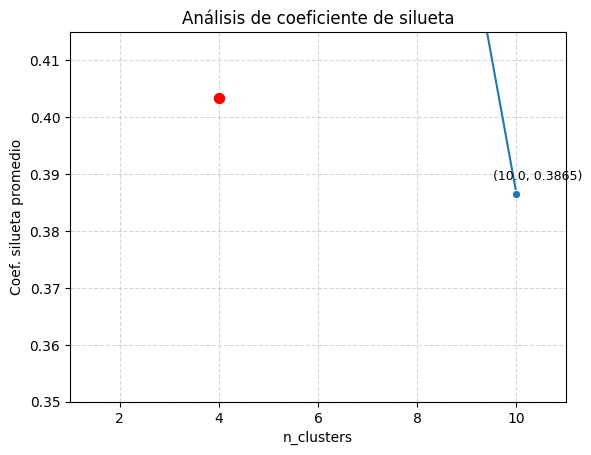

In [ ]:
silhouette_df = pd.DataFrame(silhouette_data, columns=['n_cluster', 'cs'])

sns.lineplot(data=silhouette_df, x='n_cluster', y='cs', marker='o')
sns.scatterplot(x=[4], y=[0.4034], color='red', s=80, zorder=5)

for x, y in zip(silhouette_df["n_cluster"], silhouette_df["cs"]):
    plt.annotate(f'{x, np.round(y, 4)}', (x, y), textcoords="offset points", xytext=(15,10), ha='center', fontsize=9)

plt.title('Análisis de coeficiente de silueta')
plt.xlabel('n_clusters')
plt.ylabel('Coef. silueta promedio')
plt.grid(linestyle='--', alpha=0.5)
# plt.ylim([0.35, 0.415])
# plt.xlim([1, 11])
plt.savefig(f'./graphs/training/coef_silueta_line.png')

n_clusters_opt = int(silhouette_data[np.argmax(silhouette_data[:, 1]), 0])
print(f'El n_cluster optimo {n_clusters_opt}')

### Entrenamiento del Modelo de Clasificación

Una vez identificado el número de grupos (supongamos que el "codo" está en 3 o 4 clusters), ejecutamos el entrenamiento final.

In [27]:
# Entrenamos con el número de clusters elegido (ejemplo: 4)
model = KMeans(n_clusters=n_clusters_opt, init='k-means++', random_state=42)
clusters = model.fit_predict(X_unsupervised)

# Añadimos la clasificación a nuestro DataFrame original
# data_fixed['cluster_id'] = clusters

### Gráfico de Dispersión 2D (Visualización Estándar)

Primero, asegúrate de tener en un solo lugar los componentes y las etiquetas de los clusters que generó el modelo.

In [28]:
data['cluster_knn'] = clusters # Las etiquetas que generó el modelo K-Means
print(data.head())

        fecha referencia       PC1       PC2       PC3       PC4       PC5  \
0  04/06/2001         P1 -2.173814  0.560687 -0.244653 -0.000022 -0.198642   
1  04/06/2001         P2 -2.135326  0.504553 -0.095536 -0.305302 -0.183530   
2  04/06/2001         P3 -2.165984  0.458176 -0.002323 -0.326949 -0.166642   
3  04/06/2001         P4 -2.211613  0.503966 -0.129927 -0.042172 -0.189566   
4  04/07/2001         P1 -2.324292  0.460397 -0.136303  0.202740 -0.166470   

        PC6       PC7       PC8       PC9      PC10  cluster_knn  
0 -0.297102 -0.449977 -0.315806 -0.283185 -0.048349            0  
1  0.056558 -0.207734 -0.030956  0.008387 -0.057170            0  
2  0.099856 -0.208867  0.031741  0.089761  0.017689            0  
3 -0.223255 -0.443616 -0.230362 -0.179810  0.050264            0  
4 -0.296635 -0.488494 -0.353747 -0.337112  0.184335            0  


Este gráfico te permitirá ver cómo el algoritmo separó las muestras de agua. Si los grupos están bien definidos, verás "nubes" de puntos de distintos colores.

In [29]:
from pathlib import Path


def empty_directory(directory_path):
    path = Path(directory_path)
    if path.is_dir():
        return not any(path.iterdir())
    else:
        raise ValueError("This path is not a directory")

def graph_dist_clusters(data, column_names, pca_n_cols, pca_n_rows, column_analysed, output_path):

    # Verificando que el directorio para generar las graficas este vacios

    directory_path = Path(output_path).parent
    
    try:
        if empty_directory(directory_path):
            print("Directory is empty. ok")
            pca_i_row = 0
            pca_i_col = 0

            for pca_column_name_1 in column_names:

                fig_pca, ax_pca = plt.subplots(pca_n_rows, pca_n_cols, figsize=(5*pca_n_cols, 3*pca_n_rows))
                
                for pca_column_name_2 in column_names:
                    
                    sns.scatterplot(
                        data=data, 
                        x=pca_column_name_1,
                        y=pca_column_name_2,
                        hue=column_analysed,
                        palette='viridis',
                        s=15,
                        alpha=1,
                        edgecolor='w',
                        ax=ax_pca[pca_i_row, pca_i_col]
                    )

                    # Personalización de títulos (basado en tu interpretación de loadings
                    ax_pca[pca_i_row, pca_i_col].set_title(f'{pca_column_name_1} vs {pca_column_name_2}')
                    ax_pca[pca_i_row, pca_i_col].set_xlabel(f'{pca_column_name_1}')
                    ax_pca[pca_i_row, pca_i_col].set_ylabel(f'{pca_column_name_2}')
                    ax_pca[pca_i_row, pca_i_col].grid(True, linestyle='--', alpha=0.5)

                    # Actualizacón de contadores
                    if pca_i_row < pca_n_rows-1:
                        pca_i_row += 1
                    else:
                        pca_i_row = 0
                    
                    if pca_i_col < pca_n_cols-1:
                        pca_i_col += 1
                    else:
                        pca_i_col = 0
                
                plt.tight_layout()
                plt.savefig(output_path+f'{pca_column_name_1}.png')
                plt.show()
        else:
            print(f"This directory {directory_path} is not empty. Choose another one.")
    except ValueError as e:
        print(e)
    

In [30]:
column_names = data.drop(columns=['fecha', 'referencia', 'cluster_knn']).copy().columns.to_list()
pca_n_rows = 5
pca_n_cols = 2

out_path ='./graphs/training/res_knn_class_'

graph_dist_clusters(data, column_names, pca_n_cols, pca_n_rows, 'cluster_knn', out_path)

This directory graphs\training is not empty. Choose another one.


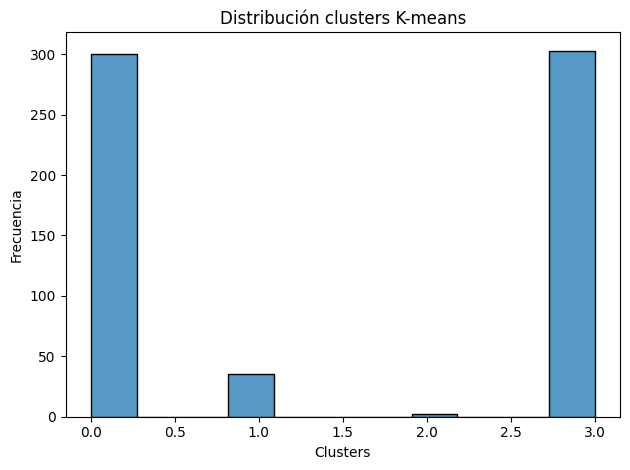

In [31]:

sns.histplot(data=data, x='cluster_knn')
plt.title('Distribución clusters K-means')
plt.xlabel(f'Clusters')
plt.ylabel(f'Frecuencia')

plt.tight_layout()
plt.savefig(f'./graphs/training/hist_res_knn.png')
plt.show()

## Entrenamiento con Autoencoder

In [32]:
# pendiente

### Híbrido ABC + K-Means (Refinamiento)
En este modelo, el ABC se encarga de la exploración global y el K-Means de la explotación local.

1. Fase Global (ABC): Las abejas exploran el espacio de datos para encontrar regiones prometedoras donde podrían estar los clusters.

2. Fase Local (K-Means): Una vez que el ABC encuentra una solución cercana a la óptima, se utiliza el operador de K-Means para "pulir" esos centroides y ajustarlos rápidamente a los datos circundantes.

Resultado: Es mucho más rápido que el ABC puro y más preciso que el K-Means solo.


### El Flujo de Trabajo

La idea central es usar el ABC para inicializar de forma inteligente los centroides y luego dejar que K-Means termine el trabajo sucio de convergencia.

1. Inicialización (Abejas Exploradoras)En lugar de elegir puntos al azar, generas una población de "abejas". Cada abeja lleva consigo un vector que representa los centros de los $k$ clusters.

- Población: $N$ soluciones potenciales.
- Posición: Coordenadas de los centros de los grupos en el espacio de datos.2. Ciclo de 

2. Optimización Global (Fase ABC)Durante un número determinado de iteraciones, las abejas realizan tres tareas:
- Abejas Empleadas: Buscan nuevas soluciones cerca de las actuales (modifican un poco los centros) para ver si el error (SSE) disminuye.
- Abejas Observadoras: Eligen las mejores soluciones encontradas basándose en una probabilidad de "fitness". Entre mejor sea el clustering, más abejas irán a esa zona.
- Abejas Exploradoras: Si una solución no mejora después de varios intentos, la abeja la abandona y vuela a una zona totalmente nueva del dataset para evitar el estancamiento.

3. El "Salto" a K-Means (Refinamiento Local)Una vez que el algoritmo ABC ha convergido en una región prometedora (es decir, ya tenemos centros muy cercanos a los reales), tomamos la mejor abeja y usamos sus posiciones como el init de un algoritmo K-Means tradicional.

4. FinalizaciónK-Means realiza sus iteraciones finales (que suelen ser muy pocas en este punto) para asegurar que cada punto esté asignado al centroide más cercano de forma exacta.

```bash
# 1. Fase Global (Exploración con ABC)
for iteracion in rango(max_iter_abc):
    for abeja in poblacion:
        nueva_posicion = mover_abeja(abeja)
        evaluar_fitness(nueva_posicion) # Usando Suma de Errores Cuadráticos
    manejar_abejas_exploradoras() # Evita mínimos locales

# 2. Selección del Ganador
mejor_solucion = obtener_mejor_abeja(poblacion)

# 3. Fase Local (Refinamiento con K-Means)
# Usamos la mejor posición del ABC como semilla
kmeans_final = KMeans(n_clusters=k, init=mejor_solucion.centros)
kmeans_final.fit(datos)
```

In [33]:
data = data.drop(columns=['fecha', 'referencia', 'cluster_knn']).copy()

# n_clusters_opt = 4
n_features = data.shape[1]

# 1.1 Función de Aptitud (Fitness)
def fitness_aptitude(solution):
    centroids = solution.reshape((n_clusters_opt, n_features))
    distances = cdist(data, centroids, 'euclidean')
    labels = np.argmin(distances, axis=1)
    
    # Penalización si se pierde un cluster
    if len(np.unique(labels)) < n_clusters_opt:
        return 1e18
    
    # Cálculo de SSE (Suma de errores cuadráticos)
    sse = 0
    for i in range(n_clusters_opt):
        cluster_points = data[labels == i]
        sse += np.sum((cluster_points - centroids[i])**2)
    return sse

# 1.2. Índice de Davies-Bouldin (DBI)
def fitness_db_index(solution):
    centroids = solution.reshape((n_clusters_opt, n_features))
    distances = cdist(data, centroids, 'euclidean')
    labels = np.argmin(distances, axis=1)
    
    if len(np.unique(labels)) < n_clusters_opt:
        return 1e18
    
    # El objetivo es MINIMIZAR este índice
    return davies_bouldin_score(data, labels)

# 1.3 Índice de Calinski-Harabasz (Varianza entre/dentro)
def fitness_calinski(solution):
    centroids = solution.reshape((n_clusters_opt, n_features))
    distances = cdist(data, centroids, 'euclidean')
    labels = np.argmin(distances, axis=1)
    
    if len(np.unique(labels)) < n_clusters_opt:
        return 1e18
    
    score = calinski_harabasz_score(data, labels)
    # Como buscamos MINIMIZAR en tu config, retornamos el negativo
    return -score

# 1.4 Función de Fitness Combinada (Híbrida)
def fitness_hybrid(solution):
    centroids = solution.reshape((n_clusters_opt, n_features))
    distances = cdist(data, centroids, 'euclidean')
    labels = np.argmin(distances, axis=1)
    
    if len(np.unique(labels)) < n_clusters_opt:
        return 1e18
    
    # 1. Calcular SSE
    sse = 0
    for i in range(n_clusters_opt):
        cluster_points = data[labels == i]
        sse += np.sum((cluster_points - centroids[i])**2)
    
    # 2. Calcular separación entre centroides (queremos que sea grande)
    # Calculamos la distancia promedio entre todos los pares de centros
    sep_distances = cdist(centroids, centroids, 'euclidean')
    # Sumamos solo la parte triangular superior para no repetir distancias ni usar la diagonal (0)
    separation = np.sum(np.triu(sep_distances, k=1))
    
    # Retornamos SSE penalizado por poca separación
    # (A menor separación, mayor el valor del fitness)
    return sse / (separation + 1e-6)

# 3. Configuración del Problema
low_bounds = np.min(data, axis=0).tolist() * n_clusters_opt
up_bounds = np.max(data, axis=0).tolist() * n_clusters_opt

problem_dict = {
    "obj_func": fitness_calinski,
    "bounds": FloatVar(lb=low_bounds, ub=up_bounds),
    "minmax": "min",
}

# 4. Ejecución de ABC
model = ABC.OriginalABC(epoch=100, pop_size=50)

# CORRECCIÓN AQUÍ: Obtenemos el objeto 'g_best' (Global Best Agent)
g_best = model.solve(problem_dict, seed=45)

# Captura de datos historicos de la solucion del modelo
history_pos = np.array([agent.solution for agent in model.history.list_global_best])

# Extraemos la posición y el fitness del objeto Agent
best_pos = g_best.solution 
best_fit = g_best.target.fitness

print(f"Mejor Fitness (SSE) encontrado por ABC: {best_fit}")


2026/04/08 08:15:21 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: OriginalABC(epoch=100, pop_size=50, n_limits=25)
2026/04/08 08:15:21 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 1, Current best: -81.80364240751487, Global best: -81.80364240751487, Runtime: 0.06917 seconds
2026/04/08 08:15:21 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 2, Current best: -81.80364240751487, Global best: -81.80364240751487, Runtime: 0.06495 seconds
2026/04/08 08:15:21 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 3, Current best: -91.50294422088416, Global best: -91.50294422088416, Runtime: 0.08574 seconds
2026/04/08 08:15:21 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 4, Current best: -91.50294422088416, Global best: -91.50294422088416, Runtime: 0.06077 seconds
2026/04/08 08:15:21 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 5, Current best: -91.50294422088416, Global best: -91.50294422088

Mejor Fitness (SSE) encontrado por ABC: -101.39681060516769


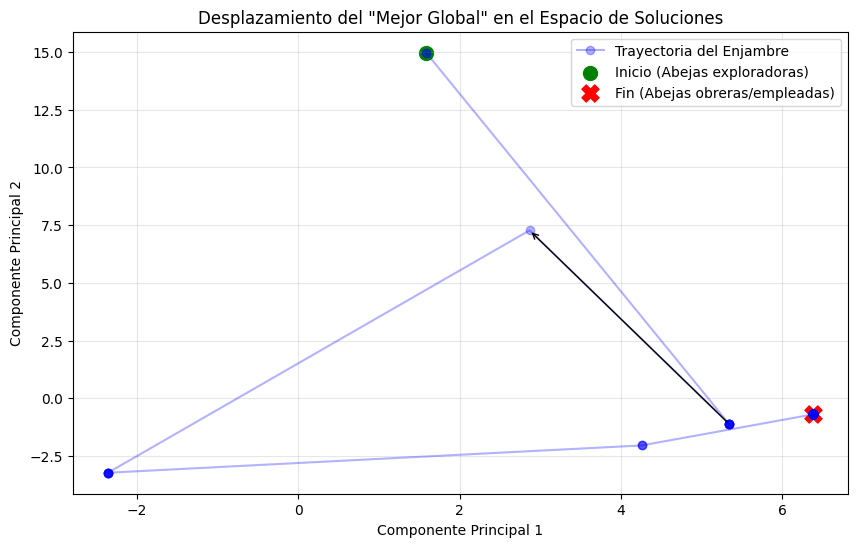

In [34]:
# Diagrmaa de resultados de algoritmo ABC-K
from sklearn.decomposition import PCA

# pca_traj = PCA(n_components=2)
# path_2d = pca_traj.fit_transform(history_pos)

path_nd = np.array([agent.solution for agent in model.history.list_global_best])

col_1_ind = 0
col_2_ind = 1

plt.figure(figsize=(10, 6))
plt.plot(path_nd[:, col_1_ind], path_nd[:, col_2_ind], color='blue', alpha=0.3, label='Trayectoria del Enjambre', linestyle="-", marker='o')
plt.scatter(path_nd[0, col_1_ind], path_nd[0, col_2_ind], color='green', s=100, label='Inicio (Abejas exploradoras)')
plt.scatter(path_nd[-1, col_1_ind], path_nd[-1, col_2_ind], color='red', marker='X', s=150, label='Fin (Abejas obreras/empleadas)')

# Añadir flechas de dirección
for i in range(0, len(path_nd)-1, 10): # Flechas cada 10 épocas para no saturar
    plt.annotate('', xy=(path_nd[i+1, col_1_ind], path_nd[i+1, col_2_ind]), 
                 xytext=(path_nd[i, col_1_ind], path_nd[i, col_2_ind]),
                 arrowprops=dict(arrowstyle='->', color='black', lw=1))

plt.title('Desplazamiento del "Mejor Global" en el Espacio de Soluciones')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [35]:
print(type(path_nd))
matriz_reshaped = path_nd.reshape((100, n_clusters_opt, n_features))
print(matriz_reshaped.shape)
print(matriz_reshaped)

<class 'numpy.ndarray'>
(100, 4, 10)
[[[ 1.58612659 14.97185844 10.57950949 ... -2.81651621  9.54860967
   -1.89631875]
  [10.22799057 -0.99270311  1.34516325 ... -2.4998615  -4.108396
   -5.82427133]
  [10.32396884  5.40179301 -4.71885462 ... -6.5704254  -0.89554735
   -5.82427133]
  [-2.36070903  6.41404041 -6.58781225 ... -0.24448724  1.28354974
   -5.01099374]]

 [[ 1.58612659 14.97185844 10.57950949 ... -2.81651621  9.54860967
   -1.89631875]
  [10.22799057 -0.99270311  1.34516325 ... -2.4998615  -4.108396
   -5.82427133]
  [10.32396884  5.40179301 -4.71885462 ... -6.5704254  -0.89554735
   -5.82427133]
  [-2.36070903  6.41404041 -6.58781225 ... -0.24448724  1.28354974
   -5.01099374]]

 [[ 5.34249456 -1.10829361 -5.14577794 ... -3.23149486  6.34280787
   -0.30992998]
  [ 1.22761411  3.14821322 -1.0786866  ... -6.35083119  7.25079155
    1.42197138]
  [ 5.3472024  16.58007471 10.60037271 ...  5.05563673 -0.81683636
   -0.98482146]
  [10.40601226 -1.68277676  2.59882122 ...  2.5802

In [36]:
# 5. FASE HÍBRIDA: Refinamiento Local con K-Means
# Usamos los centros encontrados por las abejas como semilla
init_centroids = best_pos.reshape((n_clusters_opt, n_features))

kmeans_final = KMeans(n_clusters=n_clusters_opt, init=init_centroids, n_init=1, max_iter=500)
data['cluster_abck'] = kmeans_final.fit_predict(data)

print(f"Refinamiento K-Means completado. SSE Final: {kmeans_final.inertia_}")

display(data.head())

Refinamiento K-Means completado. SSE Final: 5555.456219957258


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,cluster_abck
0,-2.173814,0.560687,-0.244653,-0.000022,-0.198642,-0.297102,-0.449977,-0.315806,-0.283185,-0.048349,3
1,-2.135326,0.504553,-0.095536,-0.305302,-0.183530,0.056558,-0.207734,-0.030956,0.008387,-0.057170,3
2,-2.165984,0.458176,-0.002323,-0.326949,-0.166642,0.099856,-0.208867,0.031741,0.089761,0.017689,3
3,-2.211613,0.503966,-0.129927,-0.042172,-0.189566,-0.223255,-0.443616,-0.230362,-0.179810,0.050264,3
4,-2.324292,0.460397,-0.136303,0.202740,-0.166470,-0.296635,-0.488494,-0.353747,-0.337112,0.184335,3


In [37]:
print(matriz_reshaped[:,1,:][-1,0])

2.498477450002892


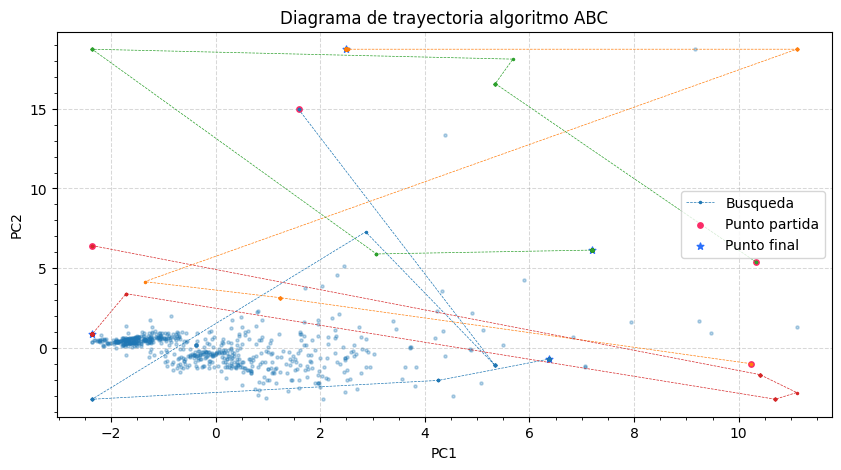

In [38]:
# indices de columas de PC
col_i_x = 0
col_i_y = 1

fig_003, ax_003 = plt.subplots(figsize=(10,5))

for c_i in range(n_clusters_opt):
    ax_003.plot(matriz_reshaped[:,c_i,:][:,col_i_x], matriz_reshaped[:,c_i,:][:,col_i_y], '.--', linewidth=0.5, markersize=3)
    ax_003.scatter(matriz_reshaped[:,c_i,:][0,col_i_x], matriz_reshaped[:,c_i,:][0,col_i_y], marker='o', s=15, color="#fb2b67")
    ax_003.scatter(matriz_reshaped[:,c_i,:][-1,col_i_x],matriz_reshaped[:,c_i,:][-1,col_i_y], marker='*', s=25, color="#2b6ffb")

ax_003.scatter(data["PC1"], data["PC2"], s=5, alpha=0.30)
    
ax_003.grid(color="gray", alpha=0.30, linewidth=0.75, linestyle='dashed')
ax_003.set_xlabel("PC1")
ax_003.set_ylabel("PC2")
ax_003.minorticks_on()
ax_003.legend([f"Busqueda", "Punto partida", "Punto final"])
ax_003.set_title("Diagrama de trayectoria algoritmo ABC")
plt.show()

In [39]:
out_path ='./graphs/training/res_abck_class_'

graph_dist_clusters(data, column_names, pca_n_cols, pca_n_rows, 'cluster_abck', out_path)

This directory graphs\training is not empty. Choose another one.


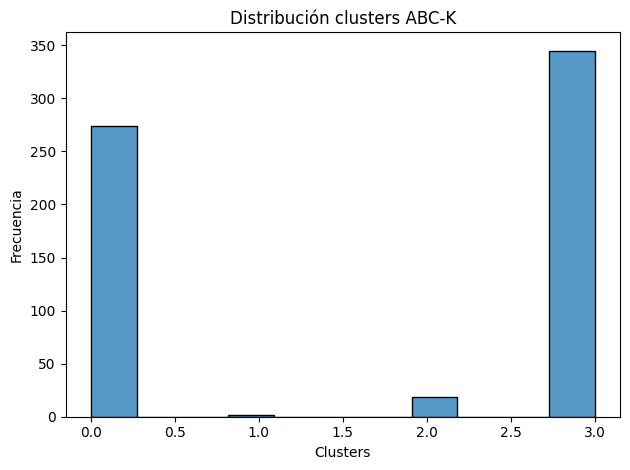

In [40]:
sns.histplot(data=data, x='cluster_abck')
plt.title('Distribución clusters ABC-K')
plt.xlabel(f'Clusters')
plt.ylabel(f'Frecuencia')

plt.tight_layout()
plt.savefig(f'./graphs/training/hist_res_abck.png')
plt.show()

In [41]:
display(data.head())
data.to_csv("./results/pca_data_abck.csv", index=False, sep=',', encoding='utf-8')

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,cluster_abck
0,-2.173814,0.560687,-0.244653,-0.000022,-0.198642,-0.297102,-0.449977,-0.315806,-0.283185,-0.048349,3
1,-2.135326,0.504553,-0.095536,-0.305302,-0.183530,0.056558,-0.207734,-0.030956,0.008387,-0.057170,3
2,-2.165984,0.458176,-0.002323,-0.326949,-0.166642,0.099856,-0.208867,0.031741,0.089761,0.017689,3
3,-2.211613,0.503966,-0.129927,-0.042172,-0.189566,-0.223255,-0.443616,-0.230362,-0.179810,0.050264,3
4,-2.324292,0.460397,-0.136303,0.202740,-0.166470,-0.296635,-0.488494,-0.353747,-0.337112,0.184335,3


### Convirtiendo modelo a binario

In [42]:
joblib.dump(kmeans_final.cluster_centers_, './binary/cluster_centers.joblib')

['./binary/cluster_centers.joblib']